In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

In [3]:
testdata=pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

In [4]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [16]:
missingper=data.isnull().sum()/len(data)*100

In [20]:
missingper[missingper>0].sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [31]:
drop_cols=missingper[missingper>80].index.tolist()

In [33]:
data=data.drop(drop_cols,axis=1)

In [36]:
#top correlators with price
corr = data.select_dtypes('number').corr()['SalePrice'].sort_values(ascending=False)

In [37]:
corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [42]:
corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

In [45]:
drop_cols=corr.tail(7).index.tolist()

In [47]:
df=data.drop(drop_cols,axis=1)

In [48]:
df.shape

(1460, 70)

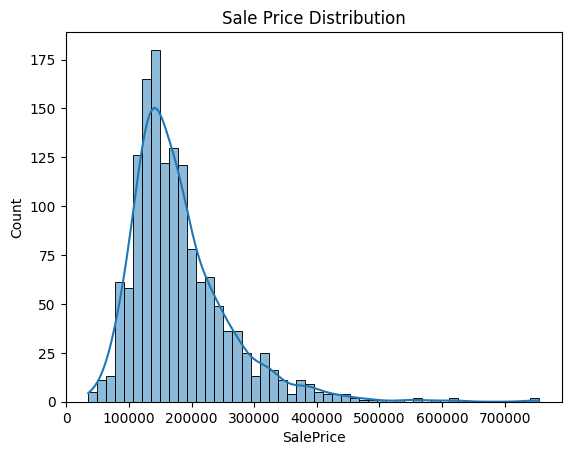

In [55]:
#heatmap
sns.histplot(df['SalePrice'],bins=50,kde=True)
plt.title("Sale Price Distribution")
plt.show()


**so as we can see from the data above the price is right skewed so to fix is it we can use log transform**

In [56]:
df['SalePrice']=np.log1p(df['SalePrice'])

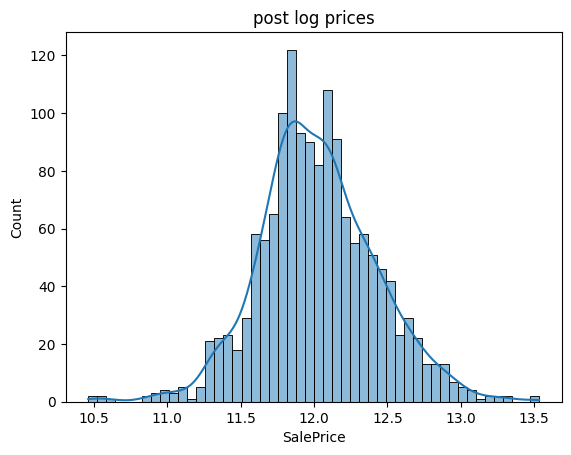

In [59]:
#plotting after log
sns.histplot(df['SalePrice'],bins=50,kde=True)
plt.title("post log prices")
plt.show()

# Data Preprocessing 

In [84]:
#importing libs
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [158]:
x=df.drop('SalePrice',axis=1)

In [159]:
y=df['SalePrice']

In [160]:
#splitting the data into numerical vs categorical
num_cols=x.select_dtypes('number').columns.tolist()
cat_cols=x.select_dtypes('object').columns.tolist()

In [161]:
num_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [162]:
col_pipe=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [163]:
preprocessor=ColumnTransformer([
    ('num',num_pipe,num_cols),
    ('cols',col_pipe,cat_cols)
])

In [164]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# **model **

In [165]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [166]:
pipe=Pipeline([
    ('prep',preprocessor),
    ('model',XGBRegressor(n_estimators=1000,random_state=42,verbosity=0))
])

In [167]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LotFrontage', 'LotArea',
                                                   'OverallQual', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'GrLivArea', 'BsmtFullBath',
                                                   'BsmtHalfBath', '...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [168]:
y_pred=pipe.predict(x_test)

In [169]:
y_pred=np.expm1(y_pred)

In [170]:
y_test=np.expm1(y_test)

In [171]:
r2=r2_score(y_test,y_pred)

In [172]:
r2

0.9078919842999936

In [174]:
rmse=mean_squared_error(y_test,y_pred)

In [175]:
print(f"RMSE:  ${rmse:,.0f}")

RMSE:  $706,498,527


# Hyperparameters tuning

In [198]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = Pipeline([
        ('prep',  preprocessor),
        ('model', XGBRegressor(**params, random_state=42, verbosity=0))
    ])
    # neg_root_mean_squared_error — higher is better (less negative)
    scores = cross_val_score(model, x_train, y_train,
                             cv=5, scoring='neg_root_mean_squared_error')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best CV RMSE (log scale):", round(-study.best_value, 4))
print("Best params:", study.best_params)

Best CV RMSE (log scale): 0.128
Best params: {'n_estimators': 568, 'learning_rate': 0.023163226418932654, 'max_depth': 5, 'subsample': 0.6246204040949763, 'colsample_bytree': 0.5004285946776235, 'reg_alpha': 4.103973320570324e-05, 'reg_lambda': 1.0767652821172138}


In [203]:
best_model = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBRegressor(**study.best_params, random_state=42, verbosity=0))
])
best_model.fit(x_train, y_train)
y_pred_tuned = np.expm1(best_model.predict(x_test))

results = pd.DataFrame({
    'Model':  ['XGBoost baseline', 'XGBoost tuned'],
    'RMSE':   [f"${rmse:,.0f}", f"${np.sqrt(mean_squared_error(y_test, y_pred_tuned)):,.0f}"],
    'R²':     [f"{r2:.3f}", f"{r2_score(y_test, y_pred_tuned):.3f}"]
})
print(results.to_string(index=False))

           Model         RMSE    R²
XGBoost baseline $706,498,527 0.908
   XGBoost tuned      $25,445 0.916
